In [1]:
!pip install tensorflow

# simple ANN with simple Dataset 

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [3]:
data = {
    "Age":[25,30,45,35,22,40,50,28,33,38],
    "Salary":[30000,40000,80000,60000,25000,90000,100000,45000,50000,75000],
    "Experience":[1,3,10,7,1,12,15,4,5,9],
    "Purchased":[0,0,1,1,0,1,1,0,1,1]
}

df = pd.DataFrame(data)
print(df)

   Age  Salary  Experience  Purchased
0   25   30000           1          0
1   30   40000           3          0
2   45   80000          10          1
3   35   60000           7          1
4   22   25000           1          0
5   40   90000          12          1
6   50  100000          15          1
7   28   45000           4          0
8   33   50000           5          1
9   38   75000           9          1


In [4]:
X = df.drop("Purchased", axis=1)#input
y = df["Purchased"]#output

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


build the deep learning model -with certain layers and activation functions

In [6]:
model = Sequential([
    Dense(units=8,activation="relu",input_shape=(3,)),

    Dense(units=6,activation="relu"),

    Dense(units=1,activation="sigmoid")
])

c:\Users\Dell\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# check how ur model looks

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93 (372.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=1,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5000 - loss: 0.6469 - val_accuracy: 0.0000e+00 - val_loss: 0.7170
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6221 - val_accuracy: 0.5000 - val_loss: 0.6966
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.6025 - val_accuracy: 0.5000 - val_loss: 0.6697
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6667 - loss: 0.5827 - val_accuracy: 0.5000 - val_loss: 0.6440
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 0.5620 - val_accuracy: 1.0000 - val_loss: 0.6209
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 0.5448 - val_accuracy: 1.0000 - val_loss: 0.5976
Epoch 7/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.5251 - val_accuracy: 1.0000 - val_loss: 0.5783
Epoch 8/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8333 - loss: 0.5080 - val_accuracy: 1.0000 - val_loss: 0.5589


we always try to look into val_accuracy and val_loss , to estimate that how its going to be performing on the unseen data 
adjust your hyperparameters based on the losses what u see , get good score of validations 


Rule of thumb
When evaluating deep learning models, the gap between training and validation performance is often more important than training accuracy itself. A model with 92% train accuracy and 90% validation accuracy is usually much healthier than a model with 100% train accuracy and 50% validation accuracy

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss:", loss)

print(f"Accuracy: {accuracy*100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5000 - loss: 0.6471
Loss: 0.6471425294876099
Accuracy: 50.00


In [11]:
new_customer = np.array([[29, 55000, 5]])

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[[0.39511117]]


c:\Users\Dell\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


* Q1. Rebuild the dataset with realistic scale and imbalance.
Regenerate the Age / Salary / Experience / Purchased dataset with at least 800 records, and
deliberately skew it so roughly 80% of customers did not purchase and 20% did. Print the class
distribution.

In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 800

age = np.random.randint(18, 66, n)              # 18-65 years
salary = np.random.randint(20000, 150001, n)    # 20k-150k
experience = np.random.randint(0, 41, n)        # 0-40 years

In [13]:
# set an estimated values that says yeah with these values of salary , exp , age , he will pruchase
score = ( 0.00002 * salary + 0.05 * experience + 0.01 * age )

threshold = np.percentile(score, 80)

purchased = (score > threshold).astype(int)


In [14]:
df = pd.DataFrame({
    'Age': age,
    'Salary': salary,
    'Experience': experience,
    'Purchased': purchased
})

print(df.head())

   Age  Salary  Experience  Purchased
0   56   64238          25          0
1   46   21252          28          0
2   32   59764          20          0
3   60   97709          10          0
4   25   57441          39          0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         800 non-null    int32
 1   Salary      800 non-null    int32
 2   Experience  800 non-null    int32
 3   Purchased   800 non-null    int64
dtypes: int32(3), int64(1)
memory usage: 15.8 KB


In [16]:
print(df['Purchased'].value_counts())

print("\nPercentage Distribution:")
print(df['Purchased'].value_counts(normalize=True) * 100)

Purchased
0    640
1    160
Name: count, dtype: int64

Percentage Distribution:
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64


es, exactly! You've got it.
There are two separate ideas here:
1. Calculate a score using features
    score = (
    0.00002 * salary +
    0.05 * experience +
    0.01 * age
)


2. Force the dataset to become 80:20
After scores are calculated:
        threshold = np.percentile(score, 80)
   This says:
   Find the score that separates the top 20% from the bottom 80%.


   purchased = (score > threshold).astype(int)

* Q2. Engineer new features from the existing columns.
Add these to the dataframe and display the first five rows.
● Salary_per_Experience = Salary / (Experience + 1)
● Age_Bucket = categorical bins such as 18-25, 26-35, 36-45, 46+
● An interaction term between Age and Salary

In [17]:
df['Salary_per_Experince'] = df['Salary']/df['Age']
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince
0,56,64238,25,0,1147.107143
1,46,21252,28,0,462.000000
2,32,59764,20,0,1867.625000
3,60,97709,10,0,1628.483333
4,25,57441,39,0,2297.640000


In [18]:
df['Salary_per_Experince'].astype('float32')
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince
0,56,64238,25,0,1147.107143
1,46,21252,28,0,462.000000
2,32,59764,20,0,1867.625000
3,60,97709,10,0,1628.483333
4,25,57441,39,0,2297.640000


In [19]:
df['Age_Bucket'] = pd.cut(df['Age'], bins=[18, 26, 36, 46, float('inf')],
                     labels=['18-25', '26-35', '36-45', '46+'],
                    include_lowest=True)
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Bucket
0,56,64238,25,0,1147.107143,46+
1,46,21252,28,0,462.000000,36-45
2,32,59764,20,0,1867.625000,26-35
3,60,97709,10,0,1628.483333,46+
4,25,57441,39,0,2297.640000,18-25


In [20]:
df["Age_Salary_interaction"] = df["Age"] * df["Salary"]
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Bucket,Age_Salary_interaction
0,56,64238,25,0,1147.107143,46+,3597328
1,46,21252,28,0,462.000000,36-45,977592
2,32,59764,20,0,1867.625000,26-35,1912448
3,60,97709,10,0,1628.483333,46+,5862540
4,25,57441,39,0,2297.640000,18-25,1436025


* Q3. Compare encoding strategies for Age_Bucket.
Encode Age_Bucket once using One-Hot Encoding and once using Label Encoding. Train identical
ANNs on each version and compare accuracy and the number of input features created.

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["Age_Bucket"]=encoder.fit_transform(df["Age_Bucket"])

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     800 non-null    int32  
 1   Salary                  800 non-null    int32  
 2   Experience              800 non-null    int32  
 3   Purchased               800 non-null    int64  
 4   Salary_per_Experince    800 non-null    float64
 5   Age_Bucket              800 non-null    int64  
 6   Age_Salary_interaction  800 non-null    int32  
dtypes: float64(1), int32(4), int64(2)
memory usage: 31.4 KB


In [22]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)

import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9563 - loss: 0.1202 
12.02324628829956
95.6250011920929


In [23]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

dff = df.copy()

encoded = enc.fit_transform(dff[['Age_Bucket']])

ohe_cols = enc.get_feature_names_out(['Age_Bucket'])
encode_df = pd.DataFrame(encoded, columns=ohe_cols, index=dff.index)

dff = pd.concat([dff.drop(columns=['Age_Bucket']), encode_df], axis=1)

dff.head(100)



,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Salary_interaction,Age_Bucket_0,Age_Bucket_1,Age_Bucket_2,Age_Bucket_3
0,56,64238,25,0,1147.107143,3597328,0.0,0.0,0.0,1.0
1,46,21252,28,0,462.000000,977592,0.0,0.0,1.0,0.0
2,32,59764,20,0,1867.625000,1912448,0.0,1.0,0.0,0.0
3,60,97709,10,0,1628.483333,5862540,0.0,0.0,0.0,1.0
4,25,57441,39,0,2297.640000,1436025,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
95,42,38777,2,0,923.261905,1628634,0.0,0.0,1.0,0.0
96,24,113229,36,1,4717.875000,2717496,1.0,0.0,0.0,0.0
97,26,71745,39,0,2759.423077,1865370,1.0,0.0,0.0,0.0
98,41,128464,25,1,3133.268293,5267024,0.0,0.0,1.0,0.0


In [24]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=dff.drop(['Purchased'],axis=1)
y=dff['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)

import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9375 - loss: 0.1968 
19.683338701725006
93.75


One-hot encoding creating n columns for n unique categories is often good, not bad—because it avoids the biggest problem of label/ordinal encoding: it incorrectly implies ordering.

Why one-hot is “good”

Each category gets its own feature, and the model can learn an independent weight for each category.
With Label Encoding, categories are treated like numbers (e.g., “46+” > “26-35”), which can mislead an ANN/linear model.
For moderate cardinality (a few to tens of unique values), this works very well.
When it can be “bad”

If Age_Bucket (or any category) has very large cardinality (hundreds/thousands of unique values), one-hot makes the feature matrix wide → slower training and higher memory use.
Your suggestion (“just one column with 0/1 for a unique”)

For one category, you can’t represent multiple categories with a single binary column. You need one dimension per category (or a compressed representation).
If you use only one numeric column (like label encoding), you’re back to an “ordered” representation problem.
Better alternatives for large uniques

Target encoding (encode category with mean target; use CV to avoid leakage)
Frequency encoding (encode with count/percentage)
Hashing trick (e.g., FeatureHasher) to map many categories into a fixed number of columns
Embeddings (best for deep learning; learned dense vectors instead of sparse one-hot)
For your specific case (Age_Bucket)

Age_Bucket has only 4 bins (18-25, 26-35, 36-45, 46+), so one-hot will create just 4 columns—this is absolutely fine and typically the right choice.
So: one-hot isn’t inherently bad; it’s bad mainly when the number of unique categories is huge. For your Age_Bucket, it’s beneficial.

* Q4. Detect and treat outliers in Salary.
Use the IQR method to flag Salary outliers. Report how many rows are affected, then train the ANN
with and without those rows removed and compare results.

In [25]:
import pandas as pd

# df = your dataframe
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
outlier_mask = (df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)
df['Salary_outlier'] = outlier_mask

num_outliers = outlier_mask.sum()
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower bound={lower_bound}, Upper bound={upper_bound}")
print(f"Number of outlier rows in Salary: {num_outliers}")

# Optional: view the outlier rows
# print(df.loc[outlier_mask, ['Salary']].head())


Q1=50639.25, Q3=121338.5, IQR=70699.25
Lower bound=-55409.625, Upper bound=227387.375
Number of outlier rows in Salary: 0


In [26]:
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Bucket,Age_Salary_interaction,Salary_outlier
0,56,64238,25,0,1147.107143,3,3597328,False
1,46,21252,28,0,462.000000,2,977592,False
2,32,59764,20,0,1867.625000,1,1912448,False
3,60,97709,10,0,1628.483333,3,5862540,False
4,25,57441,39,0,2297.640000,0,1436025,False


Q5. Check multicollinearity between features.
Compute the correlation matrix for Age, Salary, Experience and their engineered features, and
calculate the Variance Inflation Factor (VIF) for each. Decide whether any feature should be dropped
before modeling.

Correlation matrix:
                             Age    Salary  Experience  Purchased  \
Age                     1.000000  0.063169   -0.044183   0.078151   
Salary                  0.063169  1.000000   -0.016508   0.533531   
Experience             -0.044183 -0.016508    1.000000   0.453737   
Purchased               0.078151  0.533531    0.453737   1.000000   
Salary_per_Experince   -0.555165  0.709332    0.012172   0.344621   
Age_Bucket              0.951521  0.068106   -0.051640   0.072643   
Age_Salary_interaction  0.602924  0.792187   -0.039120   0.458978   
Salary_outlier               NaN       NaN         NaN        NaN   

                        Salary_per_Experince  Age_Bucket  \
Age                                -0.555165    0.951521   
Salary                              0.709332    0.068106   
Experience                          0.012172   -0.051640   
Purchased                           0.344621    0.072643   
Salary_per_Experince                1.000000   -0.551071  

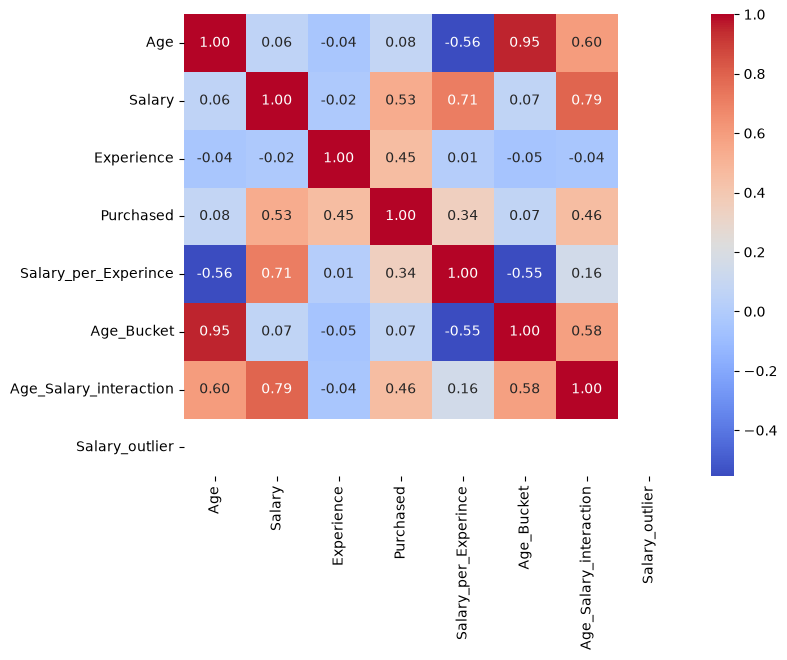

In [27]:
import numpy as np
import pandas as pd

corr = df.corr(numeric_only=True)
print("Correlation matrix:")
print(corr)

# Optional: visualize nicely (uncomment if using matplotlib)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# 2) Multicollinearity check: report highly correlated pairs


* Q6. Use a stratified train-test split.
Split the data 80/20 using stratify=y so the Purchased ratio is preserved in both sets. Print the class
distribution of y_train and y_test to confirm.

In [28]:
from sklearn.model_selection import train_test_split

x = df.drop('Purchased', axis=1)
y = df['Purchased']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('y_train distribution:')
print(y_train.value_counts(normalize=True) * 100)

print('\ny_test distribution:')
print(y_test.value_counts(normalize=True) * 100)


y_train distribution:
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64

y_test distribution:
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64


Q7. Compare scaling strategies.
Scale the features once with StandardScaler and once with MinMaxScaler. Train the same ANN
architecture on each and compare final accuracy, loss, and convergence speed

In [29]:
df.head()


,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Bucket,Age_Salary_interaction,Salary_outlier
0,56,64238,25,0,1147.107143,3,3597328,False
1,46,21252,28,0,462.000000,2,977592,False
2,32,59764,20,0,1867.625000,1,1912448,False
3,60,97709,10,0,1628.483333,3,5862540,False
4,25,57441,39,0,2297.640000,0,1436025,False


In [36]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler


# drop multiple columns to create inputs
# If 'Purchased' might be missing, print available columns
print(df.columns)

# Drop whatever exists (prevents KeyError)
X = df.drop(columns=['Purchased', 'Salary_outlier'], errors='ignore')
y = df['Purchased']

print(X)


x_train , x_test , y_train , y_test = train_test_split(X, y,test_size=0.2, random_state=42)

scaler = StandardScaler()

x_trained = scaler.fit_transform(x_train)
x_tested = scaler.transform(x_test)

import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)



Index(['Age', 'Salary', 'Experience', 'Purchased', 'Salary_per_Experince',
       'Age_Bucket', 'Age_Salary_interaction', 'Salary_outlier'],
      dtype='str')
     Age  Salary  Experience  Salary_per_Experince  Age_Bucket  \
0     56   64238          25           1147.107143           3   
1     46   21252          28            462.000000           2   
2     32   59764          20           1867.625000           1   
3     60   97709          10           1628.483333           3   
4     25   57441          39           2297.640000           0   
..   ...     ...         ...                   ...         ...   
795   47   81120          27           1725.957447           3   
796   34   39250           6           1154.411765           1   
797   65   41172          31            633.415385           3   
798   64   31555          10            493.046875           3   
799   40  107410           9           2685.250000           2   

     Age_Salary_interaction  
0                

In [38]:
df1 = df.copy()

print(df1.columns)

# Drop whatever exists (prevents KeyError)
X = df1.drop(columns=['Purchased', 'Salary_outlier'], errors='ignore')
y = df1['Purchased']

print(X)


x_train , x_test , y_train , y_test = train_test_split(X, y,test_size=0.2, random_state=42)

scaler = MinMaxScaler()

x_trained = scaler.fit_transform(x_train)
x_tested = scaler.transform(x_test)

import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)


Index(['Age', 'Salary', 'Experience', 'Purchased', 'Salary_per_Experince',
       'Age_Bucket', 'Age_Salary_interaction', 'Salary_outlier'],
      dtype='str')
     Age  Salary  Experience  Salary_per_Experince  Age_Bucket  \
0     56   64238          25           1147.107143           3   
1     46   21252          28            462.000000           2   
2     32   59764          20           1867.625000           1   
3     60   97709          10           1628.483333           3   
4     25   57441          39           2297.640000           0   
..   ...     ...         ...                   ...         ...   
795   47   81120          27           1725.957447           3   
796   34   39250           6           1154.411765           1   
797   65   41172          31            633.415385           3   
798   64   31555          10            493.046875           3   
799   40  107410           9           2685.250000           2   

     Age_Salary_interaction  
0                

Q8. Handle the class imbalance created in Q1.
Train the ANN once using the class_weight parameter in model.fit(), and once after oversampling the
minority class with SMOTE. Compare precision, recall, and F1-score for the 'Purchased' class between
the two approaches.
Q9. Create a proper train / validation / test

Q9. Create a proper train / validation / test split.
Split the data into three sets (for example 70/15/15) instead of just train/test. Justify why a separate
validation set is necessary once hyperparameter tuning begins.

In [39]:
df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experince,Age_Bucket,Age_Salary_interaction,Salary_outlier
0,56,64238,25,0,1147.107143,3,3597328,False
1,46,21252,28,0,462.000000,2,977592,False
2,32,59764,20,0,1867.625000,1,1912448,False
3,60,97709,10,0,1628.483333,3,5862540,False
4,25,57441,39,0,2297.640000,0,1436025,False


In [40]:
from sklearn.model_selection import train_test_split

# df = your dataframe
# x = input features, y = target
x = df.drop('Purchased', axis=1)
y = df['Purchased']

# 70% train, 15% val, 15% test
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.50,   # splits remaining 30% into 15% + 15%
    random_state=42,
    stratify=y_temp
)

print("y_train %:\n", (y_train.value_counts(normalize=True) * 100).round(2))
print("y_val %:\n", (y_val.value_counts(normalize=True) * 100).round(2))
print("y_test %:\n", (y_test.value_counts(normalize=True) * 100).round(2))


y_train %:
 Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64
y_val %:
 Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64
y_test %:
 Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64


If you tune hyperparameters using the test set, the model starts “seeing” the test data indirectly (via repeated choices that improve test performance). That leads to data leakage and overly optimistic test accuracy.

but usasully validation set is taken from training itself right during model fit , is it also dataleakage or what , as its trained on trainset , similar wil be the validation set

Validation set taken from the training data inside fit() (e.g., validation_split=0.2 or validation_data=(x_val, y_val)) is not leakage by itself, because it is never used to compute the final unbiased performance.
It is a “tuning” set: you use it to select hyperparameters (learning rate, epochs, architecture choices, early stopping, etc.).
Leakage happens when you use the test set for tuning/model selection, or when you fit preprocessing on the full dataset (including test).
So the rule is:

train → fit model weights
val → tune/early stop/hyperparameter selection
test → final report only (used once at the end)
This is why having a separate val set is necessary: the moment you start tuning, you need a set dedicated to that, otherwise you indirectly start tuning on the test set.